In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve,
                             average_precision_score,
                             confusion_matrix, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Load processed data and recreate exact same split as Phase 5
df = pd.read_csv('/Users/darshanv/credit-risk-scorer/data/application_train_processed.csv')

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42  # same seed = exact same split as Phase 5
)

# Load champion model
model = joblib.load('/Users/darshanv/credit-risk-scorer/models/champion_lightgbm.pkl')
feature_names = joblib.load('/Users/darshanv/credit-risk-scorer/models/feature_names.pkl')

# Get predictions on test set
test_proba = model.predict_proba(X_test)[:, 1]

print(f"Test set size: {X_test.shape}")
print(f"Champion model loaded successfully")
print(f"ROC-AUC on test set: {roc_auc_score(y_test, test_proba):.4f}")

Test set size: (61503, 77)
Champion model loaded successfully
ROC-AUC on test set: 0.7597


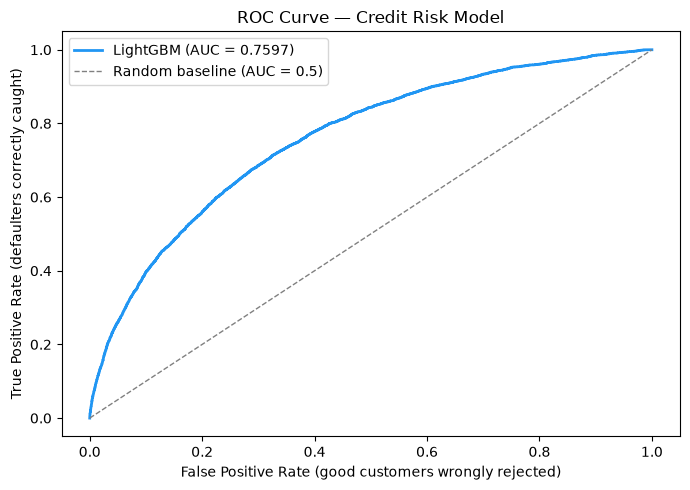

In [2]:
# ROC Curve shows the tradeoff between
# True Positive Rate (catching real defaulters)
# and False Positive Rate (wrongly flagging good customers)
# at every possible threshold

fpr, tpr, thresholds = roc_curve(y_test, test_proba)
auc_score = roc_auc_score(y_test, test_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#2196F3', lw=2,
        label=f'LightGBM (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1,
        linestyle='--', label='Random baseline (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (good customers wrongly rejected)')
ax.set_ylabel('True Positive Rate (defaulters correctly caught)')
ax.set_title('ROC Curve — Credit Risk Model')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/roc_curve.png', dpi=150)
plt.show()

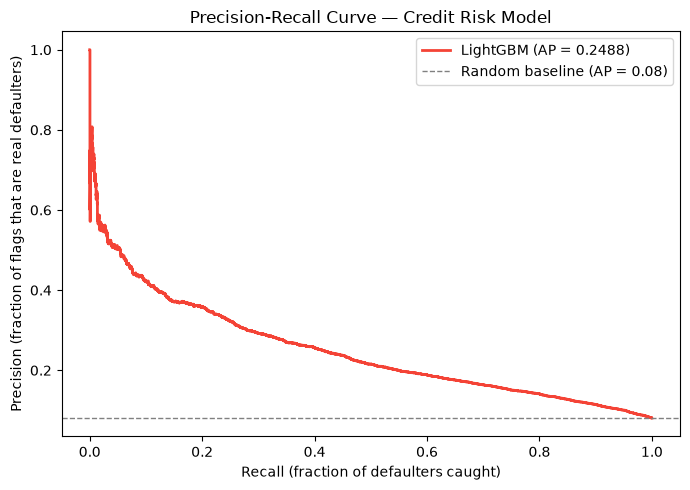

In [3]:
# For imbalanced datasets, Precision-Recall curve
# tells a more honest story than ROC curve
# because it focuses only on the minority class (defaulters)

precision, recall, pr_thresholds = precision_recall_curve(y_test, test_proba)
ap_score = average_precision_score(y_test, test_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='#F44336', lw=2,
        label=f'LightGBM (AP = {ap_score:.4f})')
ax.axhline(y=0.08, color='gray', lw=1, linestyle='--',
           label='Random baseline (AP = 0.08)')
ax.set_xlabel('Recall (fraction of defaulters caught)')
ax.set_ylabel('Precision (fraction of flags that are real defaulters)')
ax.set_title('Precision-Recall Curve — Credit Risk Model')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/pr_curve.png', dpi=150)
plt.show()

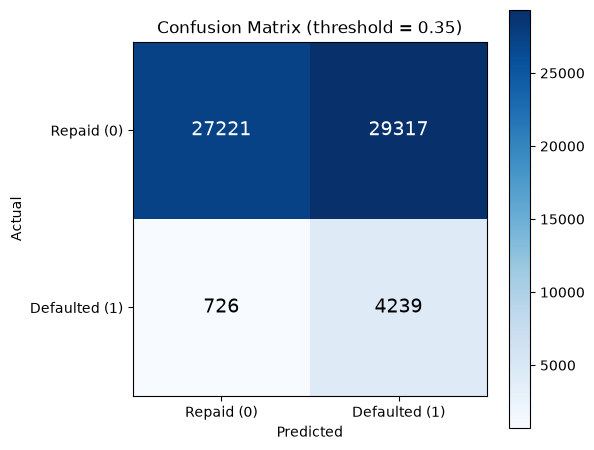


At threshold 0.35:
True Negatives  (correctly approved): 27,221
False Positives (wrongly rejected):   29,317
False Negatives (missed defaulters):  726
True Positives  (caught defaulters):  4,239


In [4]:
# Using threshold 0.35 — better recall for lending context
# where missing a defaulter is more costly than rejecting a good customer

best_threshold = 0.35
y_pred = (test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

classes = ['Repaid (0)', 'Defaulted (1)']
tick_marks = [0, 1]
ax.set_xticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticks(tick_marks)
ax.set_yticklabels(classes)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=14)

ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title(f'Confusion Matrix (threshold = {best_threshold})')
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/confusion_matrix.png', dpi=150)
plt.show()

print(f"\nAt threshold {best_threshold}:")
print(f"True Negatives  (correctly approved): {cm[0,0]:,}")
print(f"False Positives (wrongly rejected):   {cm[0,1]:,}")
print(f"False Negatives (missed defaulters):  {cm[1,0]:,}")
print(f"True Positives  (caught defaulters):  {cm[1,1]:,}")

In [5]:
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd

thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results = []

for thresh in thresholds:
    preds = (test_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    results.append({
        'Threshold': thresh,
        'Caught defaulters (TP)': tp,
        'Missed defaulters (FN)': fn,
        'Wrongly rejected (FP)': fp,
        'Correctly approved (TN)': tn,
        'Ratio (FP per TP)': round(fp/tp, 1),
        'Recall': round(tp/(tp+fn), 3),
        'Precision': round(tp/(tp+fp), 3),
        'F1': round(f1_score(y_test, preds), 4)
    })

df_thresh = pd.DataFrame(results)
print(df_thresh.to_string(index=False))

 Threshold  Caught defaulters (TP)  Missed defaulters (FN)  Wrongly rejected (FP)  Correctly approved (TN)  Ratio (FP per TP)  Recall  Precision     F1
      0.10                    4945                      20                  54839                     1699               11.1   0.996      0.083 0.1527
      0.15                    4892                      73                  50931                     5607               10.4   0.985      0.088 0.1610
      0.20                    4775                     190                  45531                    11007                9.5   0.962      0.095 0.1728
      0.25                    4640                     325                  39796                    16742                8.6   0.935      0.104 0.1879
      0.30                    4462                     503                  34310                    22228                7.7   0.899      0.115 0.2040
      0.35                    4239                     726                  29317       

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve,
                             average_precision_score,
                             confusion_matrix, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Load V2 processed data
df = pd.read_csv('/Users/darshanv/credit-risk-scorer/data/application_train_processed_v2.csv')

X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Exact same split as training — random_state=42 guarantees identical test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Load V2 champion model
model = joblib.load('/Users/darshanv/credit-risk-scorer/models/champion_lightgbm_v2.pkl')

# Get predictions
test_proba = model.predict_proba(X_test)[:, 1]

print(f"Test set: {X_test.shape}")
print(f"ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}")



Test set: (61503, 110)
ROC-AUC: 0.7755


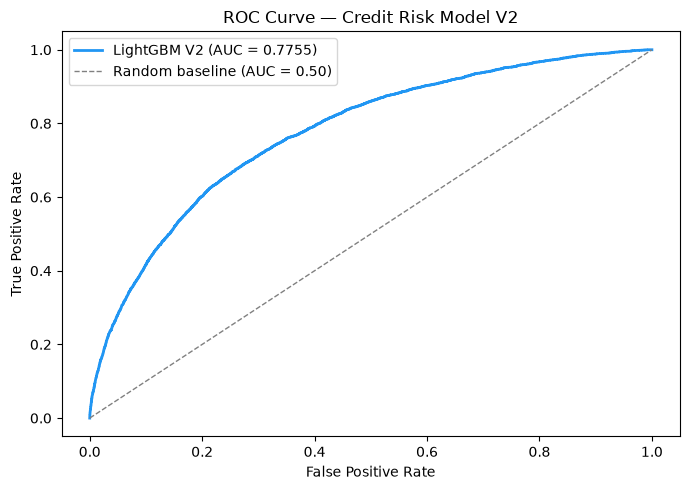

AUC improved from 0.7597 (V1) to 0.7755 (V2)


In [8]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_score = roc_auc_score(y_test, test_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#2196F3', lw=2,
        label=f'LightGBM V2 (AUC = {auc_score:.4f})')
ax.plot([0,1],[0,1], color='gray', lw=1,
        linestyle='--', label='Random baseline (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Credit Risk Model V2')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/roc_curve_v2.png', dpi=150)
plt.show()
print(f"AUC improved from 0.7597 (V1) to {auc_score:.4f} (V2)")

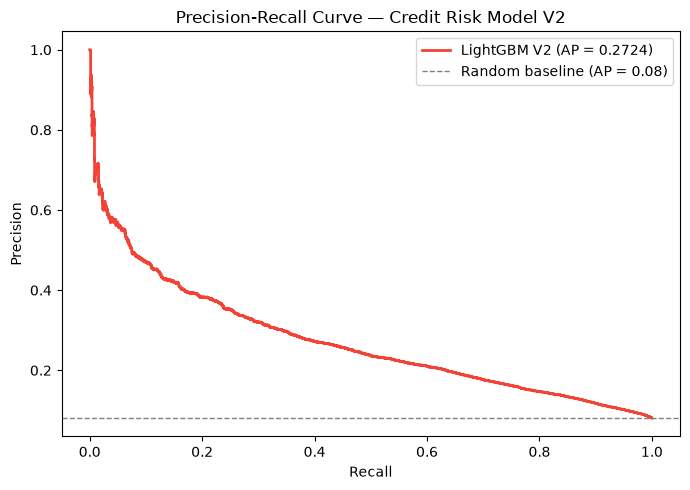

Average Precision improved from 0.2488 (V1) to 0.2724 (V2)


In [9]:
precision, recall, _ = precision_recall_curve(y_test, test_proba)
ap_score = average_precision_score(y_test, test_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='#F44336', lw=2,
        label=f'LightGBM V2 (AP = {ap_score:.4f})')
ax.axhline(y=0.08, color='gray', lw=1,
           linestyle='--', label='Random baseline (AP = 0.08)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Credit Risk Model V2')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/pr_curve_v2.png', dpi=150)
plt.show()
print(f"Average Precision improved from 0.2488 (V1) to {ap_score:.4f} (V2)")

In [10]:
import shap

print("Computing SHAP values — 2-3 minutes...")

# Sample 5000 rows for speed
X_test_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

print(f"Done. Shape: {shap_values.shape}")

Computing SHAP values — 2-3 minutes...
Done. Shape: (5000, 110)


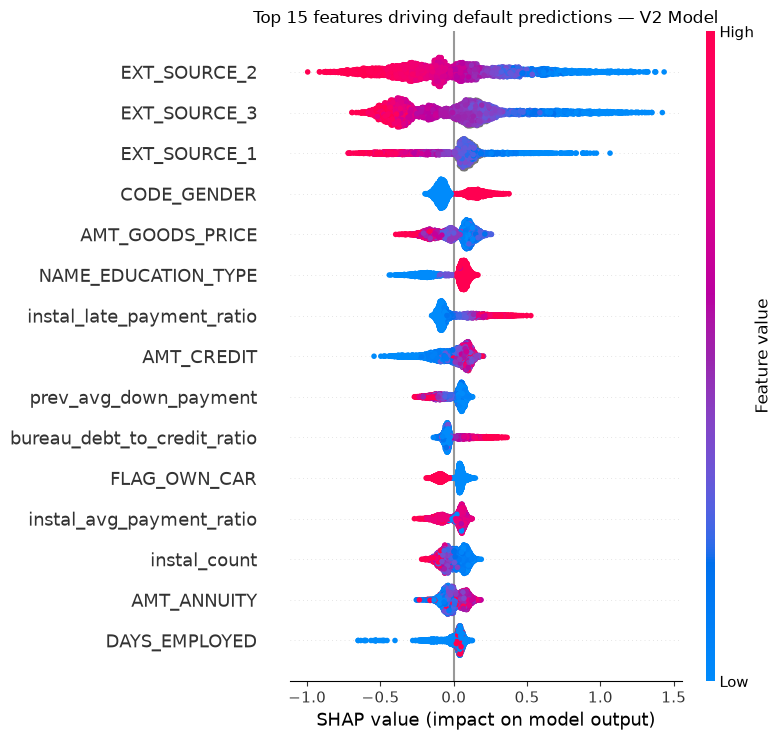

In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=15,
    show=False
)
plt.title('Top 15 features driving default predictions — V2 Model')
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/shap_summary_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
 from sklearn.metrics import confusion_matrix

# Using threshold 0.40 as recommended deployment threshold
best_threshold = 0.40
y_pred = (test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

classes = ['Repaid (0)', 'Defaulted (1)']
ax.set_xticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticks([0, 1])
ax.set_yticklabels(classes)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}',
                ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=13)

ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title(f'Confusion Matrix V2 (threshold = {best_threshold})')
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/confusion_matrix_v2.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"At threshold {best_threshold}:")
print(f"Correctly approved good customers:  {tn:,}")
print(f"Wrongly rejected good customers:    {fp:,}")
print(f"Missed defaulters:                  {fn:,}")
print(f"Caught defaulters:                  {tp:,}")
print(f"\nFP/TP ratio: {fp/tp:.1f} good customers rejected per defaulter caught")
print(f"V1 was: 6.2 at this threshold")

IndentationError: unexpected indent (3442282694.py, line 1)

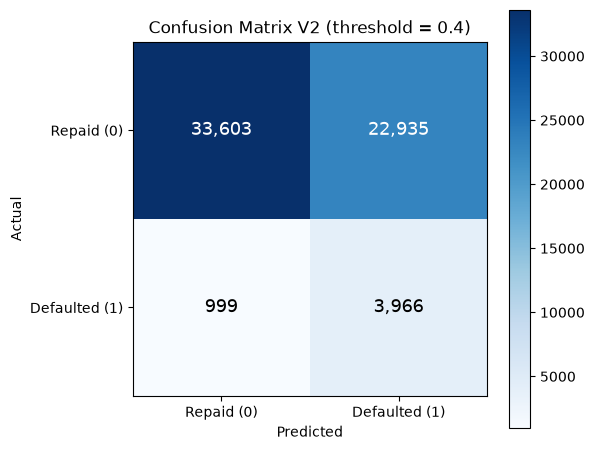

At threshold 0.4:
Correctly approved good customers:  33,603
Wrongly rejected good customers:    22,935
Missed defaulters:                  999
Caught defaulters:                  3,966

FP/TP ratio: 5.8 good customers rejected per defaulter caught
V1 was: 6.2 at this threshold


In [13]:
from sklearn.metrics import confusion_matrix

best_threshold = 0.40
y_pred = (test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

classes = ['Repaid (0)', 'Defaulted (1)']
ax.set_xticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticks([0, 1])
ax.set_yticklabels(classes)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}',
                ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=13)

ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title(f'Confusion Matrix V2 (threshold = {best_threshold})')
plt.tight_layout()
plt.savefig('/Users/darshanv/credit-risk-scorer/reports/confusion_matrix_v2.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"At threshold {best_threshold}:")
print(f"Correctly approved good customers:  {tn:,}")
print(f"Wrongly rejected good customers:    {fp:,}")
print(f"Missed defaulters:                  {fn:,}")
print(f"Caught defaulters:                  {tp:,}")
print(f"\nFP/TP ratio: {fp/tp:.1f} good customers rejected per defaulter caught")
print(f"V1 was: 6.2 at this threshold")